<a href="https://colab.research.google.com/github/dulaksha-chathura/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering/blob/main/230100M_a01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3160 Assignment 01 - Question 1
**Index Number:** 230100M
**Name:** Chandrakumara H.A.D.C.
**GitHub:** https://github.com/dulaksha-chathura/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Function Definition for Piecewise Linear Intensity Transformation
# ---------------------------------------------------------


def intensity_transform(im, breakpoints):
    """Applies piecewise linear intensity transformation based on given breakpoints.

    breakpoints: Nx2 list/array of [input_intensity, output_intensity] pairs.
    """
    # Ensure breakpoints are sorted by input intensity (x-axis)
    breakpoints = np.array(sorted(breakpoints, key=lambda x: x[0]))

    xp = breakpoints[:, 0]  # Input intensity coordinates
    fp = breakpoints[:, 1]  # Output intensity coordinates

    # Compute lookup table (LUT) using linear interpolation across [0, 255]
    lut = np.interp(np.arange(256), xp, fp).astype(np.uint8)

    # Apply lookup table transformation to image
    transformed_im = cv2.LUT(im, lut)

    return transformed_im, xp, fp


# ---------------------------------------------------------
# 2. Load the Input Image
# ---------------------------------------------------------
# Replace 'q1.jpeg' with the exact filename you uploaded to Colab
image_path = "q1.jpeg"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Sanity check to confirm image is loaded properly
if img is None:
    print(
        f"Error: Could not find '{image_path}'. Please upload it to Colab's file sidebar."
    )
else:
    # ---------------------------------------------------------
    # 3. Define Breakpoints (Given in Q1 specification)
    # ---------------------------------------------------------
    breakpoints = [[0, 0], [50, 50], [100, 150], [150, 255], [255, 255]]

    # Apply transformation
    transformed_img, x_pts, y_pts = intensity_transform(img, breakpoints)

    # ---------------------------------------------------------
    # 4. Display Results (Transformation Plot + Side-by-Side Images)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: Intensity Transformation Plot
    axes[0].plot(x_pts, y_pts, "r-o", linewidth=2, label="Transformation Curve")
    axes[0].plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity (1:1)")
    axes[0].set_title("Intensity Transformation Plot")
    axes[0].set_xlabel("Input Intensity")
    axes[0].set_ylabel("Output Intensity")
    axes[0].set_xlim([0, 255])
    axes[0].set_ylim([0, 255])
    axes[0].grid(True)
    axes[0].legend()

    # Plot 2: Original Image
    axes[1].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title("Original Image (Fig. 1b)")
    axes[1].axis("off")

    # Plot 3: Transformed Image
    axes[2].imshow(transformed_img, cmap="gray", vmin=0, vmax=255)
    axes[2].set_title("Transformed Image")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Error: Could not find 'q1.jpeg'. Please upload it to Colab's file sidebar.


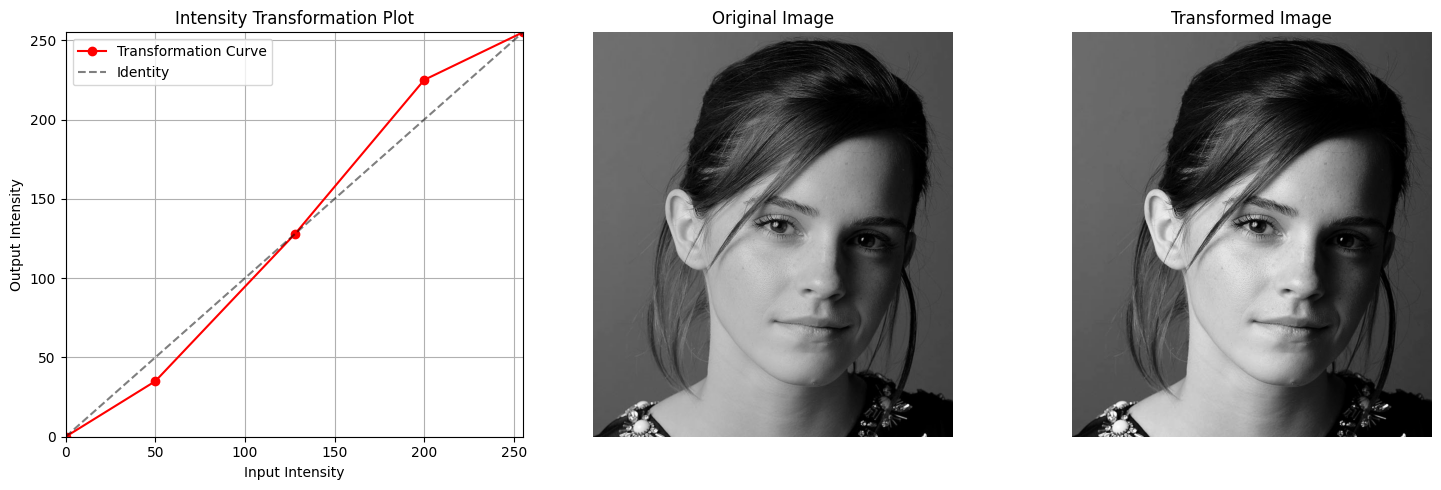

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def intensity_transform(im, breakpoints):
    bp = np.array(sorted(breakpoints, key=lambda x: x[0]))
    lut = np.interp(np.arange(256), bp[:, 0], bp[:, 1]).astype(np.uint8)
    return cv2.LUT(im, lut), bp[:, 0], bp[:, 1]


img = cv2.imread("q1.jpeg", cv2.IMREAD_GRAYSCALE)
breakpoints = [[0, 0], [50, 35], [128, 128], [200, 225], [255, 255]]

transformed_img, x_pts, y_pts = intensity_transform(img, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(x_pts, y_pts, "r-o", label="Transformation Curve")
axes[0].plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity")
axes[0].set_title("Intensity Transformation Plot")
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True)
axes[0].legend()

axes[1].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Original Image")
axes[1].axis("off")

axes[2].imshow(transformed_img, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Transformed Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Question 2: Accentuation of White Matter and Gray Matter in Brain MRI
In this task, piecewise-linear intensity transformations are applied to accentuate specific tissue regions in a brain proton density MRI slice[cite: 2]:
* **White Matter:** Represented by bright intensity values (~180–255 range).
* **Gray Matter:** Represented by intermediate intensity values (~100–170 range).

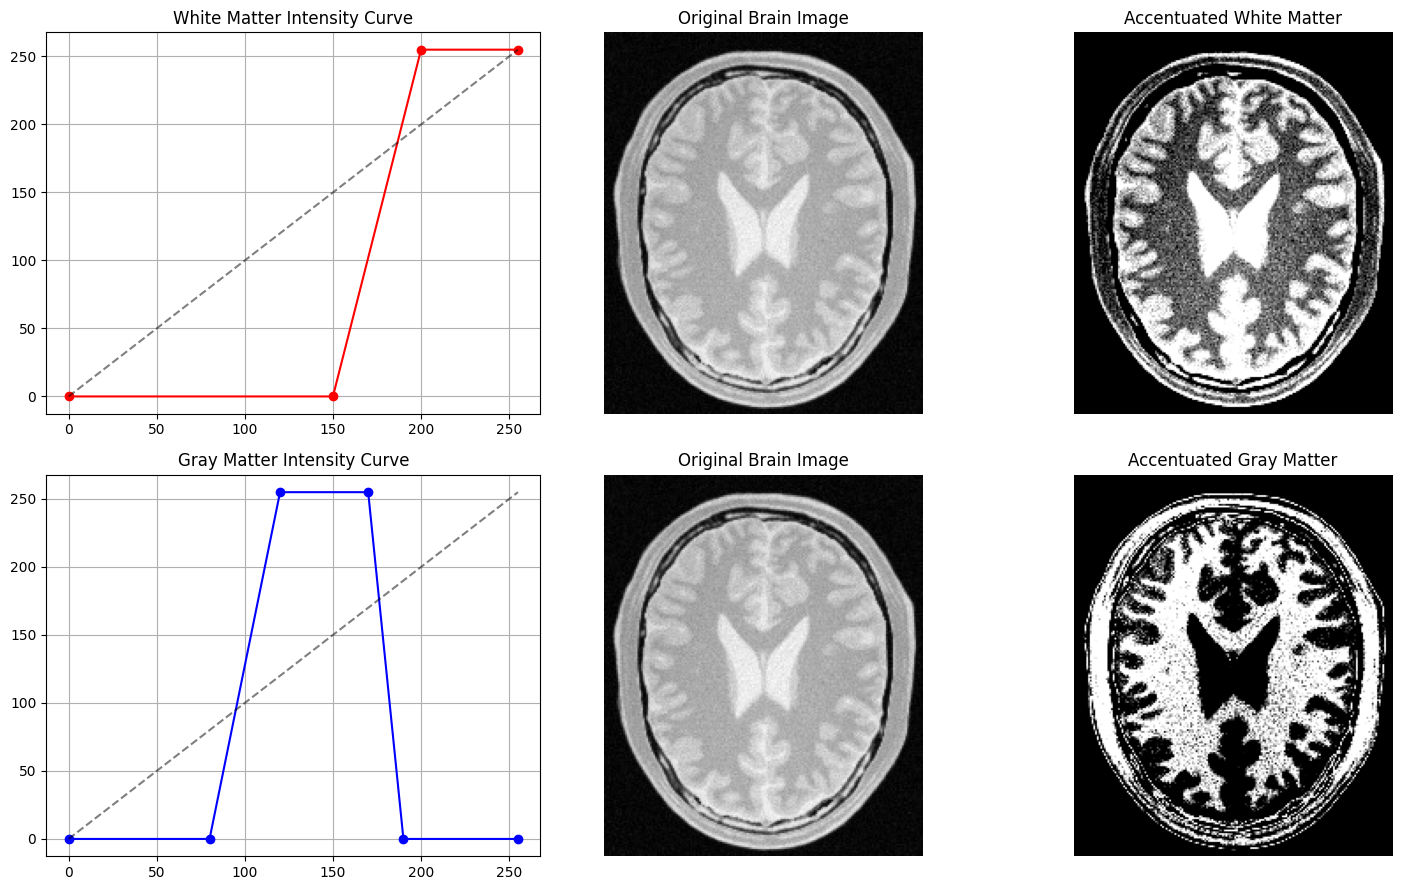

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def intensity_transform(im, breakpoints):
    bp = np.array(sorted(breakpoints, key=lambda x: x[0]))
    lut = np.interp(np.arange(256), bp[:, 0], bp[:, 1]).astype(np.uint8)
    return cv2.LUT(im, lut), bp[:, 0], bp[:, 1]


# Load brain image
img_brain = cv2.imread("q2.jpeg", cv2.IMREAD_GRAYSCALE)

# Breakpoints to accentuate White Matter (suppress mid/dark, boost high intensities)
bp_wm = [[0, 0], [150, 0], [200, 255], [255, 255]]
wm_img, x_wm, y_wm = intensity_transform(img_brain, bp_wm)

# Breakpoints to accentuate Gray Matter (isolate mid-intensity range)
bp_gm = [[0, 0], [80, 0], [120, 255], [170, 255], [190, 0], [255, 0]]
gm_img, x_gm, y_gm = intensity_transform(img_brain, bp_gm)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# White Matter Plot & Image
axes[0, 0].plot(x_wm, y_wm, "r-o", label="Transformation")
axes[0, 0].plot([0, 255], [0, 255], "k--", alpha=0.5)
axes[0, 0].set_title("White Matter Intensity Curve")
axes[0, 0].grid(True)

axes[0, 1].imshow(img_brain, cmap="gray")
axes[0, 1].set_title("Original Brain Image")
axes[0, 1].axis("off")

axes[0, 2].imshow(wm_img, cmap="gray")
axes[0, 2].set_title("Accentuated White Matter")
axes[0, 2].axis("off")

# Gray Matter Plot & Image
axes[1, 0].plot(x_gm, y_gm, "b-o", label="Transformation")
axes[1, 0].plot([0, 255], [0, 255], "k--", alpha=0.5)
axes[1, 0].set_title("Gray Matter Intensity Curve")
axes[1, 0].grid(True)

axes[1, 1].imshow(img_brain, cmap="gray")
axes[1, 1].set_title("Original Brain Image")
axes[1, 1].axis("off")

axes[1, 2].imshow(gm_img, cmap="gray")
axes[1, 2].set_title("Accentuated Gray Matter")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **White Matter Accentuation:** Setting output intensities to 0 for inputs below 150 effectively eliminates background and gray matter, highlighting the white matter tracts near the center and cortical regions.
* **Gray Matter Accentuation:** Band-pass thresholding (mapping 120–170 input range to high brightness and suppressing both dark background and bright white matter) isolates the cerebral cortex gray matter.

## Question 3: Gamma Correction on $L^*$ Plane in $L^*a^*b^*$ Color Space
Applying power-law (Gamma) correction directly to the $L^*$ (Luminance) channel adjusts perception of brightness without altering color hue or saturation[cite: 2].

Formula:
$$L_{out} = 255 \times \left(\frac{L_{in}}{255}\right)^\gamma$$

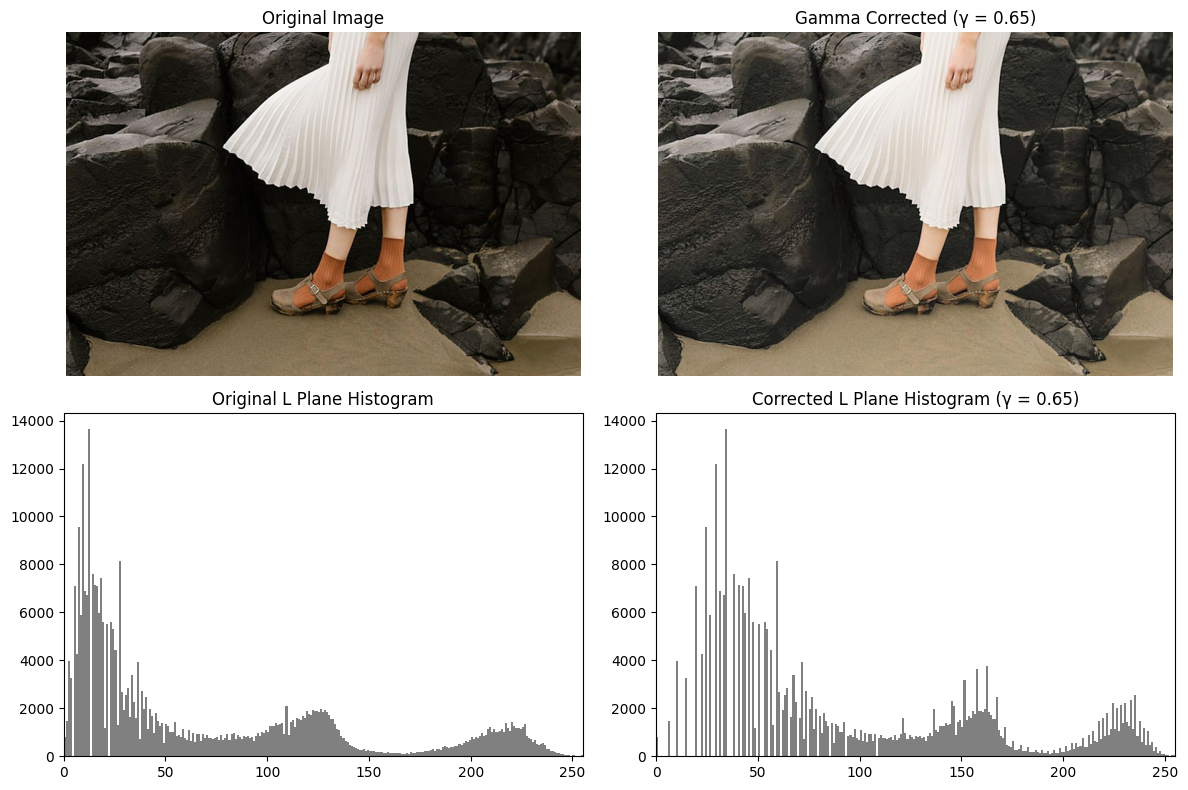

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read image
img_spider = cv2.imread("im08.jpeg")
img_rgb = cv2.cvtColor(img_spider, cv2.COLOR_BGR2RGB)

# Convert to LAB color space
img_lab = cv2.cvtColor(img_spider, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

# Gamma value selection (gamma < 1 brightens shadows/underexposed areas)
gamma = 0.65

# Apply Gamma Correction to L plane
normalized_L = L / 255.0
gamma_L = np.uint8(np.clip((normalized_L**gamma) * 255, 0, 255))

# Merge channels back and convert to RGB
lab_corrected = cv2.merge([gamma_L, a, b])
rgb_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

# Plotting Images and Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(rgb_corrected)
axes[0, 1].set_title(f"Gamma Corrected (γ = {gamma})")
axes[0, 1].axis("off")

# Histograms of L plane
axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color="gray")
axes[1, 0].set_title("Original L Plane Histogram")
axes[1, 0].set_xlim([0, 255])

axes[1, 1].hist(gamma_L.ravel(), bins=256, range=[0, 256], color="gray")
axes[1, 1].set_title(f"Corrected L Plane Histogram (γ = {gamma})")
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **Chosen $\gamma$ Value:** $\gamma = 0.65$ was chosen to brighten dark background details while keeping highlights from clipping[cite: 2].
* **Histogram Analysis:** Gamma correction non-linearly stretches lower intensity values (dark pixels) toward higher values, shifting the histogram peak to the right and improving contrast in shadowed regions.

## Question 4: Vibrance Enhancement via Saturation Transformation
Vibrance selectively increases saturation on under-saturated pixels while avoiding over-saturation of already saturated areas[cite: 2]. The transformation is:

$$f(x) = \min\left(x + a \times 128 e^{-\frac{(x-128)^2}{2\sigma^2}}, 255\right)$$
where $a \in [0,1]$ and $\sigma = 70$[cite: 2].

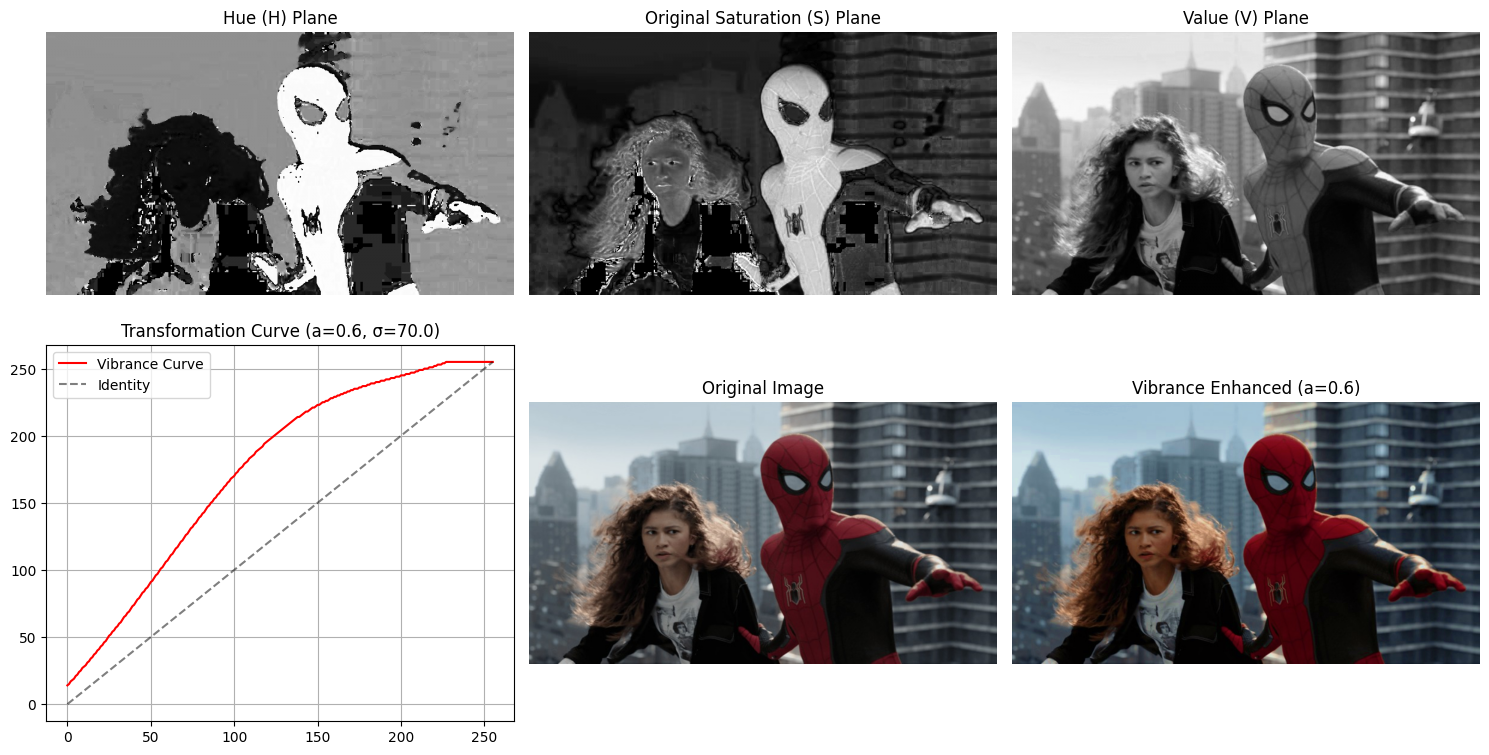

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load Image
img_vibrance = cv2.imread("im11.jpeg")
img_bgr = cv2.cvtColor(img_vibrance, cv2.COLOR_BGR2RGB)

# Convert to HSV
hsv = cv2.cvtColor(img_vibrance, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

# Parameter selection
a = 0.6  # Selected visually pleasing weight parameter
sigma = 70.0

# Apply Vibrance Transformation to Saturation channel (S)
x = np.arange(256, dtype=np.float32)
gaussian_boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma**2)))
fx = np.clip(x + gaussian_boost, 0, 255).astype(np.uint8)

# Apply LUT to S channel
S_enhanced = cv2.LUT(S, fx)

# Recombine planes and convert to RGB
hsv_enhanced = cv2.merge([H, S_enhanced, V])
rgb_enhanced = cv2.cvtColor(
    cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB
)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(H, cmap="gray")
axes[0, 0].set_title("Hue (H) Plane")
axes[0, 0].axis("off")

axes[0, 1].imshow(S, cmap="gray")
axes[0, 1].set_title("Original Saturation (S) Plane")
axes[0, 1].axis("off")

axes[0, 2].imshow(V, cmap="gray")
axes[0, 2].set_title("Value (V) Plane")
axes[0, 2].axis("off")

axes[1, 0].plot(x, fx, "r-", label="Vibrance Curve")
axes[1, 0].plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity")
axes[1, 0].set_title(f"Transformation Curve (a={a}, σ={sigma})")
axes[1, 0].grid(True)
axes[1, 0].legend()

axes[1, 1].imshow(img_bgr)
axes[1, 1].set_title("Original Image")
axes[1, 1].axis("off")

axes[1, 2].imshow(rgb_enhanced)
axes[1, 2].set_title(f"Vibrance Enhanced (a={a})")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **Effect of Gaussian Bell Curve:** The term $e^{-\frac{(x-128)^2}{2\sigma^2}}$ peaks at mid-level saturation values ($x=128$), boosting moderately saturated areas while leaving near-zero saturations and near-255 saturations mostly untouched.
* **Parameter Choice ($a = 0.6$):** $a = 0.6$ provides a natural color pop without causing unnatural skin tone shifts or color clipping artifacts[cite: 2].

## Question 5: Custom Histogram Equalization
Custom implementation of global histogram equalization using intensity probabilities and the cumulative distribution function (CDF)[cite: 2]:

$$T(k) = \text{round}\left( \frac{L - 1}{MN} \sum_{j=0}^{k} n_j \right)$$

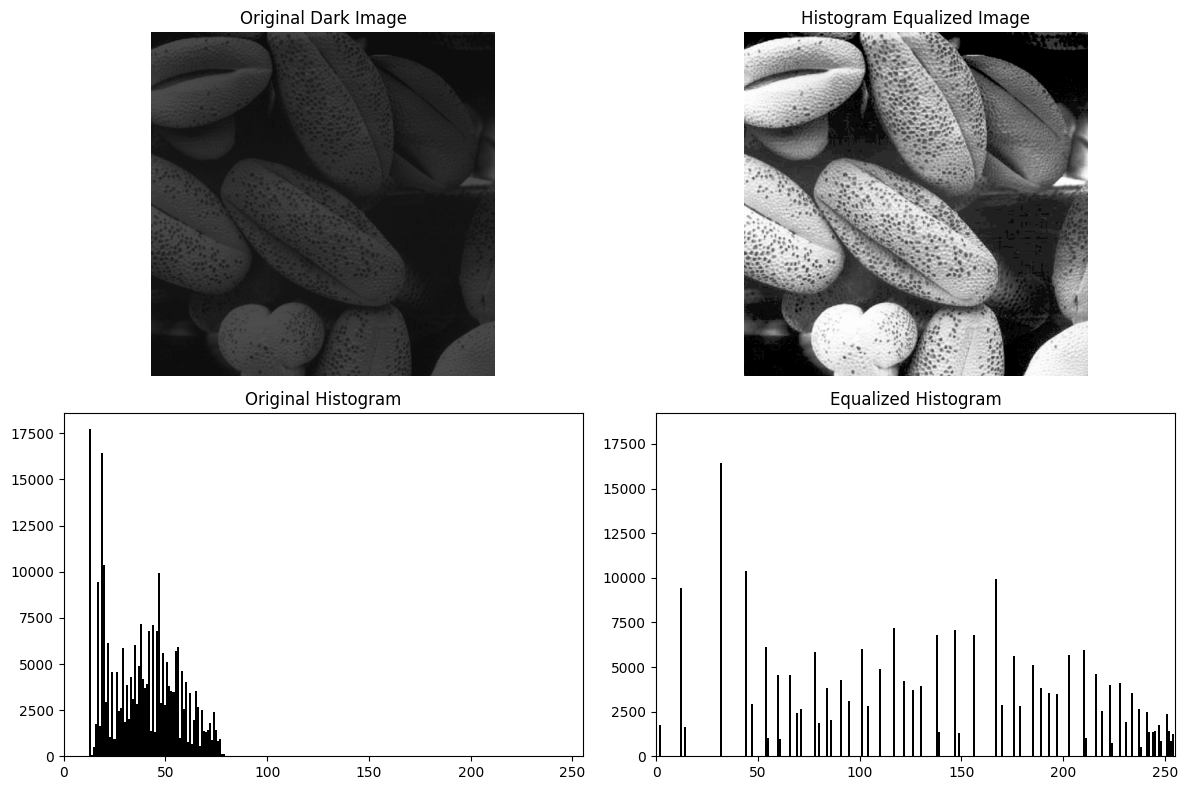

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def custom_histogram_equalization(image):
    # 1. Compute histogram
    hist, _ = np.histogram(image.flatten(), 256, [0, 256])

    # 2. Compute Cumulative Distribution Function (CDF)
    cdf = hist.cumsum()

    # 3. Mask zero values to avoid division by zero errors during normalization
    cdf_m = np.ma.masked_equal(cdf, 0)

    # 4. Apply histogram equalization formula
    cdf_m = (cdf_m - cdf_m.min()) * 255 / ((image.size) - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype("uint8")

    # 5. Map intensity values
    equalized_img = cdf_final[image]
    return equalized_img, hist, cdf_final


# Load dark input image
img_dark = cv2.imread("shells.tif", cv2.IMREAD_GRAYSCALE)
eq_img, orig_hist, lut = custom_histogram_equalization(img_dark)
eq_hist, _ = np.histogram(eq_img.flatten(), 256, [0, 256])

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img_dark, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original Dark Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(eq_img, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Histogram Equalized Image")
axes[0, 1].axis("off")

axes[1, 0].bar(range(256), orig_hist, color="black", width=1.0)
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlim([0, 255])

axes[1, 1].bar(range(256), eq_hist, color="black", width=1.0)
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **Contrast Enhancement:** The original histogram is heavily clustered in dark intensities (0–50 range). Histogram equalization redistributes pixel intensities across the full range [0, 255], revealing hidden textures and background features.
* **Discrete Histogram Spreading:** Because digital image intensity levels are discrete, the equalized histogram shows gaps between bins rather than a completely flat continuous distribution.